# Proyecto Integrador - Minería de Datos I

**Notebook 02: Calidad, Limpieza y Preparación de los Datos.**

**Objetivo**

En este notebook se realiza el proceso de limpieza y preparación del conjunto de datos. Cada transformación aplicada se encuentra respaldada por la evidencia obtenida durante la inspección inicial y se documenta indicando la acción realizada, su justificación y el impacto observado sobre el dataset.

El dataset original se mantiene sin modificaciones y las transformaciones se aplican sobre una copia de trabajo.

In [1]:
# Importación de librerías

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:.2f}".format

In [2]:
# Carga del dataset

ruta = "/content/drive/MyDrive/PI_Mineria_Datos_1/data/raw/streaming_users_dirty.json"

df = pd.read_json(ruta)

print("Dataset cargado correctamente.")

Dataset cargado correctamente.


In [3]:
# Copia de trabajo

df_limpio = df.copy()

print("Se creó una copia del dataset para realizar las transformaciones.")

Se creó una copia del dataset para realizar las transformaciones.


## Estado inicial del conjunto de datos

Antes de aplicar cualquier transformación se registra el estado inicial del dataset. Esta información servirá como referencia para evaluar el impacto de las decisiones tomadas durante el proceso de limpieza.

In [4]:
estado_inicial = pd.DataFrame({

    "Registros":[df_limpio.shape[0]],

    "Variables":[df_limpio.shape[1]],

    "Valores nulos":[df_limpio.isnull().sum().sum()],

    "Duplicados":[df_limpio.duplicated().sum()]

})

estado_inicial

,Registros,Variables,Valores nulos,Duplicados
0,8160,8,753,126


# Sección 1: Auditoría del dataset

## Auditoría de calidad de los datos

En esta sección se analizan los principales problemas de calidad presentes en el conjunto de datos. Antes de realizar cualquier transformación, se recopila evidencia que permitirá justificar las decisiones de limpieza aplicadas en las siguientes etapas.

Cada problema identificado será acompañado por la acción realizada, su justificación y el impacto observado.

In [5]:
# Auditoría de valores faltantes

nulos = pd.DataFrame({
    "Cantidad": df_limpio.isnull().sum(),
    "Porcentaje (%)": round(df_limpio.isnull().mean()*100, 2)
})

nulos = nulos[nulos["Cantidad"] > 0]
nulos.sort_values("Cantidad", ascending=False)

,Cantidad,Porcentaje (%)
last_login_date,320,3.92
favorite_genre,240,2.94
monthly_watch_time_mins,193,2.37


### Evidencia

Se identifican las variables que contienen valores faltantes y el porcentaje que representan respecto del total de registros.

Esta información permitirá decidir posteriormente si corresponde imputar valores, eliminar registros o mantener la información sin modificaciones.

In [6]:
# Auditoría de registros duplicados

duplicados = df_limpio[df_limpio.duplicated()]

print(f"Cantidad de registros duplicados: {duplicados.shape[0]}")

duplicados.head()

Cantidad de registros duplicados: 126


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
8000,10156,43,Básico,592.80,Brasil,Romance,2021-10-25,0
8001,13860,22,Básico,834.80,Chile,Romance,2021-01-05,0
8002,17431,31,Estándar,1079.80,Chile,Documental,2023-04-12,0
8005,10375,32,Premium,1223.30,Uruguay,Comedia,2020-12-22,2
8006,11988,42,Estándar,1048.00,Uruguay,Drama,2023-01-12,0


### Evidencia

Los registros duplicados representan observaciones repetidas que pueden afectar los resultados del análisis. En esta etapa se verifica su existencia antes de decidir si corresponde eliminarlos.

In [7]:
# Variables categóricas

categoricas = df_limpio.select_dtypes(include="object").columns

for columna in categoricas:

    print("="*60)
    print(f"Variable: {columna}")
    print("="*60)

    display(
        pd.DataFrame(
            df_limpio[columna].value_counts(dropna=False)
        ).head(20)
    )

Variable: subscription_plan


,count
subscription_plan,
Básico,3450
Estándar,2711
Premium,1519
basico,60
BASICO,52
Basic,52
básico,50
Std,48
Estándar,46


Variable: country


,count
country,
Brasil,1132
Chile,1132
México,1129
Uruguay,1124
Perú,1120
Colombia,1116
Argentina,1087
colombia,27
méxico,25


Variable: favorite_genre


,count
favorite_genre,
Comedia,1112
Drama,1105
Documental,1095
Romance,1090
Thriller,1090
Acción,1082
Crime,1067
None,240
Action,22


Variable: last_login_date


,count
last_login_date,
None,320
2026-15-03,20
0000-00-00,17
2029-01-01,15
not_available,14
31-02-2022,13
2019-01-17,10
2025-09-29,9
2024-08-29,9


### Evidencia

Se analizan las variables categóricas para detectar diferencias en la escritura, errores tipográficos, abreviaturas o categorías duplicadas que representen el mismo valor.

In [8]:
# Revisión de edades

print("Edad mínima:", df_limpio["age"].min())
print("Edad máxima:", df_limpio["age"].max())

df_limpio["age"].describe()

Edad mínima: -5
Edad máxima: 150


,age
count,8160.00
mean,34.10
std,14.51
min,-5.00
25%,25.00
50%,33.00
75%,42.00
max,150.00


### Evidencia

Se revisa el rango de edades para identificar valores que puedan resultar poco realistas o inconsistentes con el contexto del conjunto de datos.

In [9]:
# Tiempo mensual de visualización

df_limpio["monthly_watch_time_mins"].describe()

,monthly_watch_time_mins
count,7967.00
mean,1107.35
std,5310.44
min,-120.00
25%,489.20
50%,757.40
75%,1045.70
max,99999.00


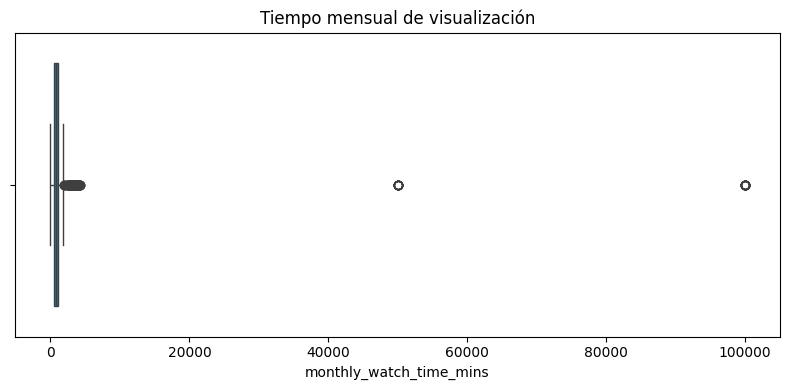

In [10]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df_limpio["monthly_watch_time_mins"])

plt.title("Tiempo mensual de visualización")

plt.tight_layout()
plt.show()

### Evidencia

El análisis descriptivo y el diagrama de caja permiten detectar posibles valores atípicos que deberán evaluarse antes de decidir si requieren tratamiento.

In [11]:
# Tickets de soporte

df_limpio["customer_support_tickets"].describe()

,customer_support_tickets
count,8160.00
mean,1.80
std,11.33
min,-1.00
25%,0.00
50%,1.00
75%,1.00
max,150.00


In [12]:
# Revisión del formato de fechas

df_limpio["last_login_date"].head(20)

,last_login_date
0,2025-03-04
1,2019-04-02
2,2018-04-13
3,2021-01-31
4,2020-09-30
5,2020-07-03
6,2019-07-26
7,2019-02-24
8,2025-08-03
9,2024-02-12


### Evidencia

Las fechas serán revisadas para verificar la consistencia de su formato y detectar posibles valores inválidos o fuera del rango esperado.

# Resumen de la auditoría

A partir de la inspección realizada se identificaron distintos aspectos que requieren tratamiento durante el proceso de preparación de los datos.

Entre ellos se destacan:

- Presencia de registros duplicados.
- Valores faltantes en algunas variables.
- Diferencias en la escritura de categorías.
- Posibles valores atípicos en variables numéricas.
- Necesidad de validar el formato y la coherencia de las fechas.

Estas evidencias servirán de fundamento para justificar cada una de las transformaciones aplicadas en las siguientes secciones.

# Problema 1: Registros duplicados

## Evidencia

Durante la auditoría inicial se detectó la existencia de registros duplicados. Estos registros representan observaciones repetidas que podrían afectar los resultados del análisis exploratorio al contabilizar la misma información más de una vez.

A continuación se verifica la cantidad de duplicados presentes en el conjunto de datos.

In [13]:
# Cantidad de registros duplicados

duplicados = df_limpio.duplicated().sum()

print(f"Registros antes de eliminar duplicados: {df_limpio.shape[0]}")
print(f"Cantidad de registros duplicados: {duplicados}")

Registros antes de eliminar duplicados: 8160
Cantidad de registros duplicados: 126


In [14]:
# Visualización de algunos registros duplicados

df_limpio[df_limpio.duplicated()].head()

,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
8000,10156,43,Básico,592.80,Brasil,Romance,2021-10-25,0
8001,13860,22,Básico,834.80,Chile,Romance,2021-01-05,0
8002,17431,31,Estándar,1079.80,Chile,Documental,2023-04-12,0
8005,10375,32,Premium,1223.30,Uruguay,Comedia,2020-12-22,2
8006,11988,42,Estándar,1048.00,Uruguay,Drama,2023-01-12,0


## Acción aplicada

Se eliminarán únicamente los registros duplicados completos, ya que representan información repetida y no aportan nuevos datos al análisis.

In [15]:
# Eliminación de registros duplicados

filas_antes = df_limpio.shape[0]

df_limpio = df_limpio.drop_duplicates()

filas_despues = df_limpio.shape[0]

print(f"Registros antes: {filas_antes}")
print(f"Registros después: {filas_despues}")
print(f"Registros eliminados: {filas_antes - filas_despues}")

Registros antes: 8160
Registros después: 8034
Registros eliminados: 126


## Resultado

Los registros duplicados fueron eliminados correctamente, conservando una única ocurrencia de cada observación repetida.

Esta transformación mejora la calidad del conjunto de datos y evita que determinadas observaciones tengan mayor peso durante el análisis exploratorio.

# Problema 2: Valores faltantes

## Evidencia

Se identifican las variables que contienen valores faltantes y el porcentaje que representan respecto del total del dataset.

El tratamiento de estos valores dependerá de la cantidad de registros afectados y del tipo de variable.

In [16]:
# Valores faltantes

nulos = pd.DataFrame({
    "Cantidad": df_limpio.isnull().sum(),
    "Porcentaje (%)": round(df_limpio.isnull().mean()*100,2)
})

nulos = nulos[nulos["Cantidad"]>0]

nulos.sort_values("Cantidad", ascending=False)

,Cantidad,Porcentaje (%)
last_login_date,320,3.98
favorite_genre,240,2.99
monthly_watch_time_mins,193,2.40


In [17]:
# Imputación de favorite_genre

moda_genero = df_limpio["favorite_genre"].mode()[0]

df_limpio["favorite_genre"] = df_limpio["favorite_genre"].fillna(moda_genero)

print("Valores faltantes restantes:")
print(df_limpio["favorite_genre"].isnull().sum())

Valores faltantes restantes:
0


### Resultado

Los valores faltantes de la variable **favorite_genre** fueron reemplazados por la categoría más frecuente (moda), permitiendo conservar la totalidad de los registros sin introducir nuevas categorías.

In [18]:
# Imputación de monthly_watch_time_mins

mediana_watch = df_limpio["monthly_watch_time_mins"].median()

df_limpio["monthly_watch_time_mins"] = (
    df_limpio["monthly_watch_time_mins"]
    .fillna(mediana_watch)
)

print("Valores faltantes restantes:")
print(df_limpio["monthly_watch_time_mins"].isnull().sum())

Valores faltantes restantes:
0


### Resultado

Los valores faltantes de la variable **monthly_watch_time_mins** fueron reemplazados por la mediana de la distribución. Se eligió esta medida debido a que es menos sensible a posibles valores extremos y permite conservar todos los registros del conjunto de datos.

## Observación

La variable **last_login_date** aún conserva valores faltantes, ya que antes de definir una estrategia de imputación es necesario verificar la consistencia de sus formatos y detectar posibles fechas inválidas o fuera del rango esperado.

Esta revisión se realizará en la siguiente sección del notebook.

# Problema 3: Inconsistencias en variables categóricas

## Evidencia

Durante la inspección inicial se observó que algunas variables categóricas presentan diferencias en la forma de escribir una misma categoría. Estas inconsistencias incluyen el uso de mayúsculas y minúsculas, espacios adicionales, abreviaturas, errores tipográficos y diferentes idiomas.

Estas diferencias pueden provocar que una misma categoría sea interpretada como valores distintos durante el análisis exploratorio. Por este motivo, se realizará un proceso de normalización para unificar la información.

In [19]:
# Categorías antes de la limpieza

categoricas = df_limpio.select_dtypes(include="object").columns

for columna in categoricas:

    print(f"\n{'='*60}")
    print(f"Variable: {columna}")
    print(f"{'='*60}")

    print(df_limpio[columna].value_counts(dropna=False))


Variable: subscription_plan
subscription_plan
Básico       3395
Estándar     2669
Premium      1490
basico         60
BASICO         52
Basic          52
básico         50
Std            48
Estándar       46
estandar       36
STANDARD       34
Premium        31
PREMIUM        26
Premiun        23
premium        22
Name: count, dtype: int64

Variable: country
country
Chile         1118
Brasil        1115
México        1106
Uruguay       1105
Colombia      1099
Perú          1096
Argentina     1075
colombia        27
méxico          25
uruguay         24
Brazil          21
COL             19
CHL             18
URY             17
argentina       16
MEX             16
Chile           16
PER             16
Peru            15
BRA             15
chile           15
Mexico          15
brasil          13
perú            12
ARG             10
Argentina       10
Name: count, dtype: int64

Variable: favorite_genre
favorite_genre
Comedia        1335
Drama          1088
Thriller       1077
Romance  

In [20]:
# Normalización básica

for columna in categoricas:

    df_limpio[columna] = (
        df_limpio[columna]
        .astype(str)
        .str.strip()
    )

In [21]:
# Normalización de subscription_plan

df_limpio["subscription_plan"] = (
    df_limpio["subscription_plan"]
    .replace({
        "basico":"Básico",
        "BASICO":"Básico",
        "Basic":"Básico",
        "básico":"Básico",
        "Basico":"Básico",


        "Std":"Estándar",
        "STANDARD":"Estándar",
        "Standard":"Estándar",
        "estandar":"Estándar",
        "Estándar ":"Estándar",
        "Estandar":"Estándar",

        "Premium":"Premium",
        "PREMIUM":"Premium",
        "Premiun":"Premium",
        "premium":"Premium"
    })
)

In [22]:
# Normalización de country

df_limpio["country"] = (
    df_limpio["country"]
    .replace({

        "Brazil":"Brasil",
        "brasil":"Brasil",
        "BRA":"Brasil",
        "Bra":"Brasil",

        "Mexico":"México",
        "méxico":"México",
        "MEX":"México",
        "Mex":"México",

        "Argentina":"Argentina",
        "argentina":"Argentina",
        "ARG":"Argentina",
        "Arg":"Argentina",

        "Colombia":"Colombia",
        "colombia":"Colombia",
        "COL":"Colombia",
        "Col":"Colombia",

        "Peru":"Perú",
        "PER":"Perú",
        "perú":"Perú",
        "Per":"Perú",

        "Chile":"Chile",
        "chile":"Chile",
        "CHL":"Chile",
        "Chl":"Chile",

        "Uruguay":"Uruguay",
        "uruguay":"Uruguay",
        "URY":"Uruguay",
        "Uru":"Uruguay",
        "Ury":"Uruguay"
    })
)

In [23]:
# Normalización de favorite_genre

df_limpio["favorite_genre"] = (
    df_limpio["favorite_genre"]
    .replace({

        "Action":"Acción",
        "accion":"Acción",
        "ACCIÓN":"Acción",
        "Accion":"Acción",

        "Comedy":"Comedia",
        "COMEDIA":"Comedia",

        "Documentary":"Documental",
        "DOC":"Documental",
        "documental":"Documental",
        "Doc" : "Documental",

        "DRAMA":"Drama",
        "drama":"Drama",

        "Thriller":"Thriller",
        "thriler":"Thriller",
        "THRILLER":"Thriller",
        "Thriler" : "Thriller",

        "Crime":"Crimen",
        "CRIME":"Crimen",
        "crime":"Crimen"
    })
)

In [24]:
print(df_limpio["subscription_plan"].value_counts())

print(df_limpio["country"].value_counts())

print(df_limpio["favorite_genre"].value_counts())

subscription_plan
Básico      3609
Estándar    2833
Premium     1592
Name: count, dtype: int64
country
Chile        1167
Brasil       1164
México       1162
Uruguay      1146
Colombia     1145
Perú         1139
Argentina    1111
Name: count, dtype: int64
favorite_genre
Comedia       1369
Drama         1121
Documental    1111
Acción        1110
Thriller      1109
Crimen        1089
Romance       1087
ROMANCE         14
comedy          12
romance         12
Name: count, dtype: int64


## Resultado

Las variables categóricas fueron normalizadas mediante la unificación de categorías equivalentes.

Esta transformación permitió reducir la cantidad de categorías duplicadas originadas por diferencias de escritura, errores tipográficos y abreviaturas, mejorando la consistencia del conjunto de datos para las etapas posteriores del análisis.

Nota: Aunque last_login_date fue identificada como tipo object, no se incluye en esta etapa de normalización porque representa una variable temporal. Su tratamiento se realizará en la sección correspondiente a la limpieza y validación de fechas.

# Problema 4: Validación y limpieza de fechas

## Evidencia

Durante la auditoría del dataset se detectó que la variable **last_login_date** presenta distintos problemas de calidad, entre ellos:

- Valores faltantes.
- Fechas con formato inválido.
- Valores no correspondientes a fechas (por ejemplo, *not_available*).
- Fechas futuras que podrían resultar inconsistentes con el período del conjunto de datos.

Por este motivo, se realizará un proceso de validación y normalización de la variable antes de utilizarla en el análisis.

In [25]:
# Valores especiales detectados

df_limpio["last_login_date"].value_counts().head(15)

,count
last_login_date,
None,320
2026-15-03,20
0000-00-00,17
2029-01-01,15
not_available,14
31-02-2022,13
2019-01-17,10
2024-08-29,9
2025-09-29,9


In [26]:
# Reemplazo de valores inválidos

df_limpio["last_login_date"] = df_limpio["last_login_date"].replace({
    "0000-00-00": np.nan,
    "not_available": np.nan,
    "None": np.nan
})

In [27]:
# Conversión a formato fecha

df_limpio["last_login_date"] = pd.to_datetime(
    df_limpio["last_login_date"],
    errors="coerce"
)

In [28]:
# Fechas futuras

fecha_actual = pd.Timestamp.today().normalize()

fechas_futuras = df_limpio[
    df_limpio["last_login_date"] > fecha_actual
]

print(f"Cantidad de fechas futuras: {len(fechas_futuras)}")

fechas_futuras.head()

Cantidad de fechas futuras: 15


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
58,10058,20,Básico,960.20,Perú,Thriller,2029-01-01,1
69,10069,21,Básico,816.20,Colombia,Documental,2029-01-01,0
162,10162,27,Estándar,1301.00,Argentina,Thriller,2029-01-01,2
737,10737,44,Básico,870.50,Perú,Thriller,2029-01-01,1
908,10908,34,Básico,1078.50,Colombia,Romance,2029-01-01,0


Se detectaron 15 registros con fechas posteriores a la fecha actual.

Dado que estas fechas no resultan consistentes con el período del conjunto de datos y no es posible determinar cuál debería ser su valor correcto, se decidió reemplazarlas por valores nulos (`NaT`).

De esta forma se conserva el resto de la información de cada registro sin introducir datos ficticios.

In [29]:
# Reemplazo de fechas futuras

fecha_actual = pd.Timestamp.today().normalize()

df_limpio.loc[
    df_limpio["last_login_date"] > fecha_actual,
    "last_login_date"
] = pd.NaT

print("Fechas futuras restantes:")

print((df_limpio["last_login_date"] > fecha_actual).sum())

Fechas futuras restantes:
0


In [30]:
print("Valores faltantes en last_login_date:")

print(df_limpio["last_login_date"].isna().sum())

Valores faltantes en last_login_date:
784


La variable last_login_date conserva valores nulos debido a que no existe una forma objetiva de reconstruir la fecha correcta sin introducir información ficticia.

## Resultado

La variable **last_login_date** fue normalizada correctamente.

Se eliminaron las fechas inválidas y las fechas futuras fueron reemplazadas por valores nulos, conservando la integridad del resto de la información de cada registro.

La columna queda preparada para su utilización durante el análisis exploratorio.

# Problema 5: Validación de la variable edad

## Evidencia

La variable **age** representa la edad de los usuarios. Durante el proceso de limpieza es importante verificar que sus valores se encuentren dentro de un rango razonable, ya que edades negativas, iguales a cero o excesivamente altas pueden indicar errores de carga.

En esta etapa se analizará la distribución de la variable y se identificarán posibles valores inconsistentes.

In [31]:
# Estadísticas de la variable age

df_limpio["age"].describe()

,age
count,8034.00
mean,34.10
std,14.56
min,-5.00
25%,25.00
50%,33.00
75%,42.00
max,150.00


In [32]:
# Edad mínima y máxima

print("Edad mínima:", df_limpio["age"].min())
print("Edad máxima:", df_limpio["age"].max())

Edad mínima: -5
Edad máxima: 150


In [33]:
# Edades fuera del rango esperado

edades_invalidas = df_limpio[
    (df_limpio["age"] < 13) |
    (df_limpio["age"] > 100)
]

print(f"Cantidad de edades fuera de rango: {len(edades_invalidas)}")

edades_invalidas.head()

Cantidad de edades fuera de rango: 120


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
49,10049,0,Básico,1081.60,Argentina,Romance,2023-02-25,0
194,10194,130,Básico,820.70,Uruguay,Drama,2018-10-11,1
310,10310,0,Estándar,877.90,Perú,Crimen,2025-06-04,0
324,10324,130,Básico,420.80,Brasil,Thriller,2023-05-07,1
426,10426,150,Premium,1315.60,Colombia,Acción,2022-12-15,1


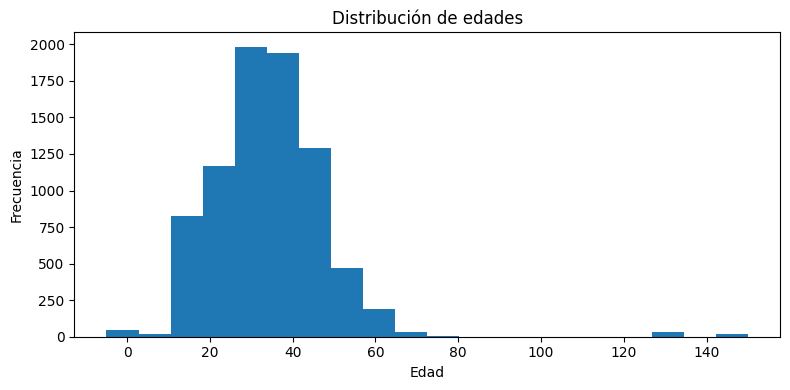

In [34]:
plt.figure(figsize=(8,4))

plt.hist(df_limpio["age"], bins=20)

plt.title("Distribución de edades")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

## Evidencia

El análisis descriptivo permite verificar si existen edades fuera del rango esperado para este conjunto de datos. En caso de encontrarse valores inconsistentes, se evaluará el tratamiento más adecuado antes de continuar con el análisis.

Se detectaron edades fuera del rango considerado válido para este proyecto (menores de 13 años y mayores de 100 años).

Dado que no es posible conocer el valor correcto de dichas edades, se decidió reemplazarlas por valores nulos. De esta forma se conserva el resto de la información asociada a cada registro sin introducir datos ficticios.

In [35]:
# Reemplazo de edades inválidas por NaN

df_limpio.loc[
    (df_limpio["age"] < 13) |
    (df_limpio["age"] > 100),
    "age"
] = np.nan

print("Edades inválidas restantes:")

print(
    ((df_limpio["age"] < 13) |
     (df_limpio["age"] > 100)).sum()
)

Edades inválidas restantes:
0


In [36]:
# Imputación de edades

mediana_edad = df_limpio["age"].median()

df_limpio["age"] = df_limpio["age"].fillna(mediana_edad)

print("Valores faltantes en age:")

print(df_limpio["age"].isna().sum())

Valores faltantes en age:
0


## Resultado

Las edades fuera del rango esperado fueron reemplazadas por valores nulos y posteriormente imputadas utilizando la mediana de la variable.

Se eligió la mediana debido a que es una medida robusta frente a valores extremos y permite conservar todos los registros del conjunto de datos sin introducir sesgos significativos.

# Problema 6: Tratamiento de valores extremos

## Evidencia

Durante la exploración de las variables numéricas se detectaron algunos valores extremadamente alejados del resto de las observaciones.

En particular, las variables **monthly_watch_time_mins** y **customer_support_tickets** presentan registros que podrían influir de manera significativa en los análisis posteriores, especialmente durante el escalamiento de datos y la aplicación de PCA.

Con el fin de conservar los registros sin eliminar información, se decidió aplicar un proceso de winsorización utilizando el rango intercuartílico (IQR).

In [37]:
# Corrección de tiempos negativos

df_limpio.loc[
    df_limpio["monthly_watch_time_mins"] < 0,
    "monthly_watch_time_mins"
] = np.nan

mediana = df_limpio["monthly_watch_time_mins"].median()

df_limpio["monthly_watch_time_mins"] = (
    df_limpio["monthly_watch_time_mins"]
    .fillna(mediana)
)

In [38]:
# Corrección de tickets negativos

df_limpio.loc[
    df_limpio["customer_support_tickets"] < 0,
    "customer_support_tickets"
] = np.nan

mediana = df_limpio["customer_support_tickets"].median()

df_limpio["customer_support_tickets"] = (
    df_limpio["customer_support_tickets"]
    .fillna(mediana)
)

In [39]:
# Función para winsorización mediante IQR

def winsorizar_iqr(df, columna):

    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    df[columna] = df[columna].clip(
        lower=limite_inferior,
        upper=limite_superior
    )

    return df

In [40]:
# Winsorización

df_limpio = winsorizar_iqr(df_limpio, "monthly_watch_time_mins")

df_limpio = winsorizar_iqr(df_limpio, "customer_support_tickets")

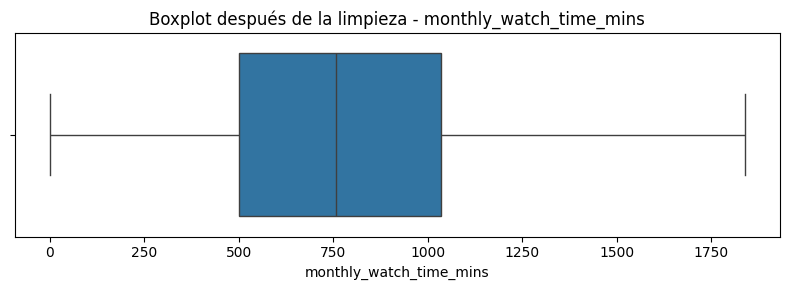

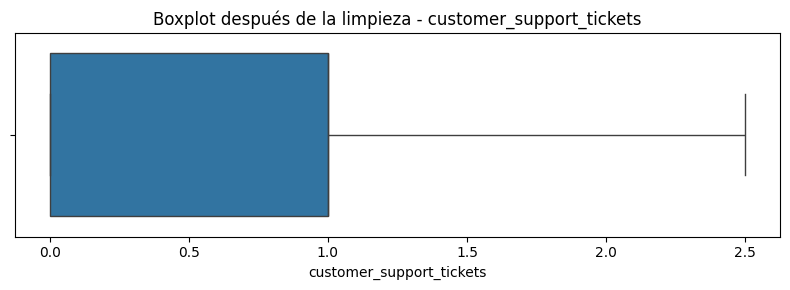

In [41]:
for columna in ["monthly_watch_time_mins", "customer_support_tickets"]:

    plt.figure(figsize=(8,3))

    sns.boxplot(x=df_limpio[columna])

    plt.title(f"Boxplot después de la limpieza - {columna}")

    plt.tight_layout()
    plt.show()

In [42]:
df_limpio[
    ["monthly_watch_time_mins",
     "customer_support_tickets"]
].describe()

,monthly_watch_time_mins,customer_support_tickets
count,8034.00,8034.00
mean,774.20,0.78
std,387.16,0.81
min,0.00,0.00
25%,499.68,0.00
50%,757.20,1.00
75%,1035.60,1.00
max,1839.49,2.50


## Resultado

Los valores extremos fueron limitados utilizando el método de winsorización basado en el rango intercuartílico (IQR).

Esta estrategia permitió reducir la influencia de observaciones extremadamente alejadas sin eliminar registros del conjunto de datos, preservando así la mayor cantidad posible de información para las etapas posteriores del análisis.

# Verificación final del conjunto de datos

Antes de guardar el dataset procesado se realiza una última verificación para comprobar que las transformaciones fueron aplicadas correctamente y que el conjunto de datos se encuentra preparado para las siguientes etapas del proyecto.

In [43]:
print("Duplicados:", df_limpio.duplicated().sum())

print("\nValores faltantes por columna:")
print(df_limpio.isnull().sum())

print("\nDimensiones del dataset:")
print(df_limpio.shape)

Duplicados: 13

Valores faltantes por columna:
user_id                       0
age                           0
subscription_plan             0
monthly_watch_time_mins       0
country                       0
favorite_genre                0
last_login_date             784
customer_support_tickets      0
dtype: int64

Dimensiones del dataset:
(8034, 8)


In [44]:
df_limpio.describe(include="all")

,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
count,8034.00,8034.00,8034,8034.00,8034,8034,7250,8034.00
unique,NaN,NaN,3,NaN,7,10,NaN,NaN
top,NaN,NaN,Básico,NaN,Chile,Comedia,NaN,NaN
freq,NaN,NaN,3609,NaN,1167,1369,NaN,NaN
mean,13999.92,33.69,NaN,774.20,NaN,NaN,2022-01-30 01:36:43.696551680,0.78
min,10000.00,13.00,NaN,0.00,NaN,NaN,2018-01-01 00:00:00,0.00
25%,11999.25,26.00,NaN,499.68,NaN,NaN,2020-01-20 00:00:00,0.00
50%,14001.50,33.00,NaN,757.20,NaN,NaN,2022-02-12 00:00:00,1.00
75%,15997.75,41.00,NaN,1035.60,NaN,NaN,2024-02-13 00:00:00,1.00
max,17999.00,80.00,NaN,1839.49,NaN,NaN,2025-12-31 00:00:00,2.50


In [45]:
import os

# Guardar dataset limpio
ruta_salida = "/content/drive/MyDrive/PI_Mineria_Datos_1/data/processed/streaming_users_clean.csv"
os.makedirs(os.path.dirname(ruta_salida), exist_ok=True)

df_limpio.to_csv(
    ruta_salida,
    index=False
)

print("Dataset procesado guardado correctamente.")

Dataset procesado guardado correctamente.


# Resumen de la preparación de los datos

Durante este notebook se realizaron las siguientes transformaciones:

- Eliminación de registros duplicados.
- Tratamiento de valores faltantes.
- Normalización de variables categóricas.
- Validación y conversión de fechas.
- Corrección de edades inconsistentes.
- Tratamiento de valores extremos mediante winsorización.

Estas transformaciones permitieron obtener un conjunto de datos consistente y preparado para el análisis exploratorio desarrollado en el siguiente notebook.

# Conclusión

En esta etapa se realizó el proceso de preparación y limpieza del conjunto de datos, aplicando transformaciones justificadas a partir de la evidencia obtenida durante la auditoría inicial.

Las decisiones adoptadas permitieron mejorar la calidad del dataset preservando la mayor cantidad posible de información y garantizando la trazabilidad de cada modificación realizada.

El conjunto de datos resultante se encuentra preparado para desarrollar el análisis exploratorio y la reducción de dimensionalidad en las siguientes etapas del proyecto.

# Registro del proceso ETL

Como parte de la trazabilidad del proyecto, se genera un registro con las principales transformaciones realizadas sobre el conjunto de datos. Este registro resume las acciones aplicadas durante el proceso de limpieza y preparación, permitiendo comparar el estado inicial y final del dataset.

In [46]:
# Creación del Pipeline Log

pipeline = pd.DataFrame({
    "Paso": [
        "Carga inicial",
        "Eliminación de duplicados",
        "Tratamiento de valores faltantes",
        "Normalización de variables categóricas",
        "Validación de fechas",
        "Corrección de edades",
        "Tratamiento de valores extremos",
        "Dataset final"
    ],

    "Descripción": [
        "Carga del dataset original.",
        "Se eliminaron registros duplicados.",
        "Imputación de valores faltantes según el tipo de variable.",
        "Unificación de categorías equivalentes.",
        "Conversión de fechas y eliminación de fechas inválidas.",
        "Corrección e imputación de edades fuera de rango.",
        "Winsorización y corrección de valores extremos.",
        "Dataset listo para el análisis exploratorio."
    ],

    "Filas": [
        8160,
        8034,
        8034,
        8034,
        8034,
        8034,
        8034,
        8034
    ],

    "Nulos": [
        753,
        627,
        784,
        784,
        784,
        784,
        784,
        784
    ],

    "Retención (%)": [
        100.00,
        round((8034/8160)*100,2),
        round((8034/8160)*100,2),
        round((8034/8160)*100,2),
        round((8034/8160)*100,2),
        round((8034/8160)*100,2),
        round((8034/8160)*100,2),
        round((8034/8160)*100,2)
    ]
})

pipeline

,Paso,Descripción,Filas,Nulos,Retención (%)
0,Carga inicial,Carga del dataset original.,8160,753,100.00
1,Eliminación de duplicados,Se eliminaron registros duplicados.,8034,627,98.46
2,Tratamiento de valores faltantes,Imputación de valores faltantes según el tipo ...,8034,784,98.46
3,Normalización de variables categóricas,Unificación de categorías equivalentes.,8034,784,98.46
4,Validación de fechas,Conversión de fechas y eliminación de fechas i...,8034,784,98.46
5,Corrección de edades,Corrección e imputación de edades fuera de rango.,8034,784,98.46
6,Tratamiento de valores extremos,Winsorización y corrección de valores extremos.,8034,784,98.46
7,Dataset final,Dataset listo para el análisis exploratorio.,8034,784,98.46


In [47]:
# Guardar Pipeline Log

pipeline.to_csv(
    "/content/drive/MyDrive/PI_Mineria_Datos_1/logs/pipeline_log.csv",
    index=False
)

print("Pipeline Log guardado correctamente.")

Pipeline Log guardado correctamente.
